# 📈 Stock Movement Prediction Analysis
This notebook contains a complete pipeline for stock price prediction using machine learning, technical indicators, and sentiment analysis.

### [Cell 1] - Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from newsapi import NewsApiClient
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style for visualizations
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

### [Cell 2] - Download Stock Data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✓ Data downloaded successfully


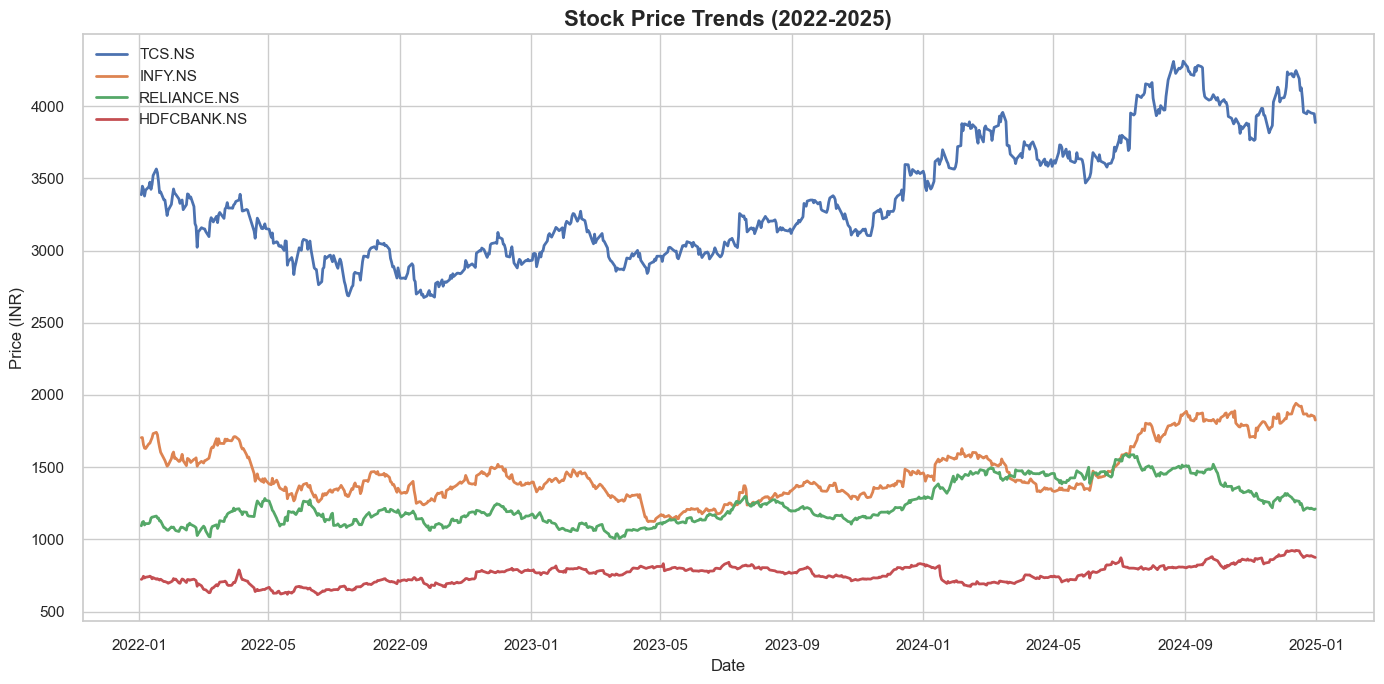

In [2]:
stocks = ["TCS.NS", "INFY.NS", "RELIANCE.NS", "HDFCBANK.NS"]

df_list = []

for stock in stocks:
    temp_df = yf.download(stock, start="2022-01-01", end="2025-01-01")
    temp_df.reset_index(inplace=True)
    if isinstance(temp_df.columns, pd.MultiIndex):
        temp_df.columns = [col[0] for col in temp_df.columns]
    temp_df['Stock'] = stock
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print("✓ Data downloaded successfully")

# Visualize Raw Stock Trends
plt.figure(figsize=(14, 7))
for stock in stocks:
    stock_data = df[df['Stock'] == stock]
    plt.plot(stock_data['Date'], stock_data['Close'], label=stock, linewidth=2)
plt.title('Stock Price Trends (2022-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### [Cell 3] - Data Info

In [3]:
print(f"\nShape: {df.shape}")
df.info()


Shape: (2956, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    2956 non-null   datetime64[s]
 1   Close   2956 non-null   float64      
 2   High    2956 non-null   float64      
 3   Low     2956 non-null   float64      
 4   Open    2956 non-null   float64      
 5   Volume  2956 non-null   int64        
 6   Stock   2956 non-null   str          
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 161.8 KB


### [Cell 4] - Data Cleaning

In [4]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.loc[:, ~df.columns.duplicated()]
required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock']
available_cols = [col for col in required_cols if col in df.columns]
df = df[available_cols]
df['Date'] = pd.to_datetime(df['Date'])
df[['Open', 'High', 'Low', 'Close', 'Volume']] = df[
    ['Open', 'High', 'Low', 'Close', 'Volume']
].astype('float32')
print("\n✓ Columns after cleaning:", df.columns.tolist())
df.head()


✓ Columns after cleaning: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock']


,Date,Open,High,Low,Close,Volume,Stock
0,2022-01-03,3326.263184,3397.223389,3321.828125,3386.357666,2346158.0,TCS.NS
1,2022-01-04,3398.198975,3449.689453,3380.990967,3445.786621,2488606.0,TCS.NS
2,2022-01-05,3428.268799,3432.703613,3381.612305,3424.676270,1733031.0,TCS.NS
3,2022-01-06,3381.257080,3401.658203,3345.776855,3377.221191,1810293.0,TCS.NS
4,2022-01-07,3388.353271,3428.179688,3367.419922,3418.067871,2460591.0,TCS.NS


### [Cell 5] - Sort and Drop Nulls

In [5]:
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)
df.dropna(inplace=True)
print(f"✓ Shape after sorting & cleaning: {df.shape}")
df.head()

✓ Shape after sorting & cleaning: (2956, 7)


,Date,Open,High,Low,Close,Volume,Stock
0,2022-01-03,3326.263184,3397.223389,3321.828125,3386.357666,2346158.0,TCS.NS
1,2022-01-03,1694.644165,1718.253906,1694.644165,1704.249634,3329616.0,INFY.NS
2,2022-01-03,706.321716,724.395935,704.181335,722.802551,9069184.0,HDFCBANK.NS
3,2022-01-03,1076.103394,1095.646118,1075.443604,1093.780518,5421611.0,RELIANCE.NS
4,2022-01-04,722.969055,729.104797,717.166260,727.035767,8857352.0,HDFCBANK.NS


### [Cell 6] - Feature Engineering

✓ Shape after feature engineering: (2947, 18)


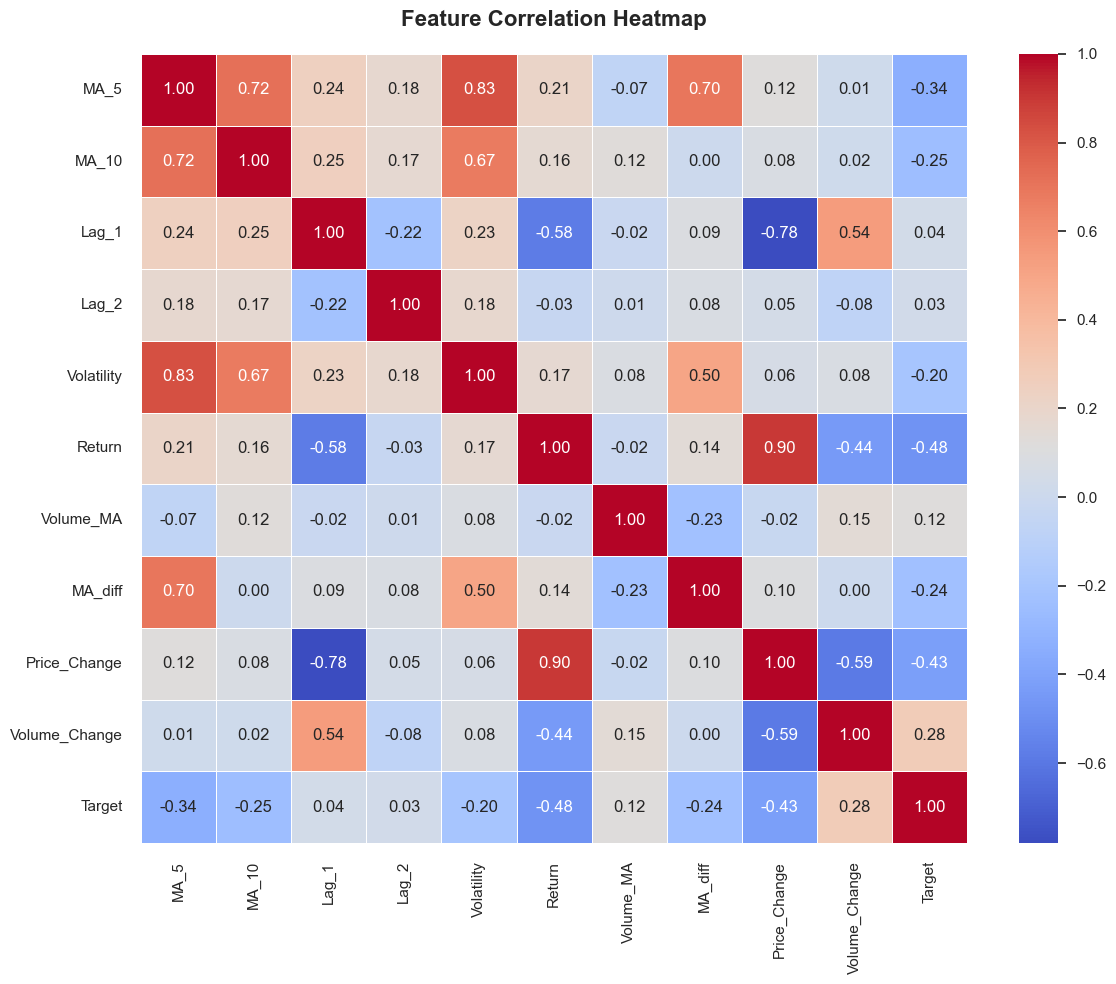

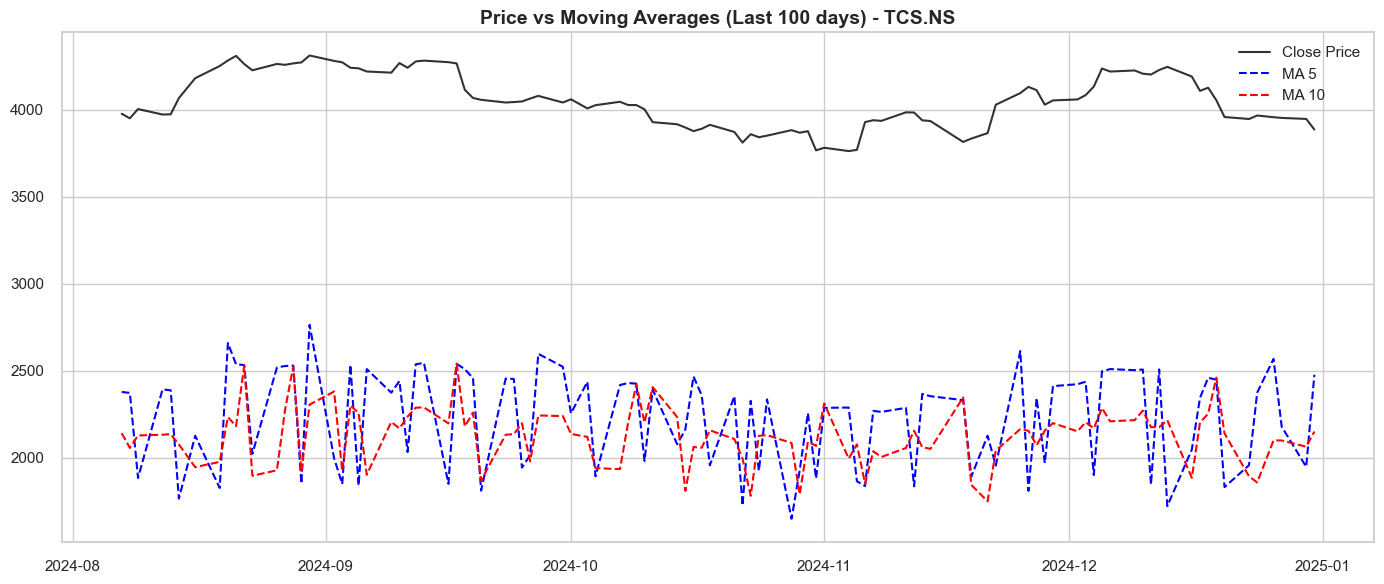

In [6]:
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Volatility'] = df['Close'].rolling(5).std()
df['Return'] = df['Close'].pct_change()
df['Volume_MA'] = df['Volume'].rolling(5).mean()
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df['MA_diff'] = df['MA_5'] - df['MA_10']
df['Price_Change'] = df['Close'] - df['Lag_1']
df['Volume_Change'] = df['Volume'].pct_change()
df.dropna(inplace=True)

features = ['MA_5', 'MA_10', 'Lag_1', 'Lag_2', 'Volatility', 'Return', 'Volume_MA', 'MA_diff', 'Price_Change', 'Volume_Change']

print(f"✓ Shape after feature engineering: {df.shape}")

# Visualize Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df[features + ['Target']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Visualize Price vs Moving Averages for a sample stock
sample_stock = "TCS.NS"
sample_df = df[df['Stock'] == sample_stock].tail(100)
plt.figure(figsize=(14, 6))
plt.plot(sample_df['Date'], sample_df['Close'], label='Close Price', color='black', alpha=0.8)
plt.plot(sample_df['Date'], sample_df['MA_5'], label='MA 5', color='blue', linestyle='--')
plt.plot(sample_df['Date'], sample_df['MA_10'], label='MA 10', color='red', linestyle='--')
plt.title(f'Price vs Moving Averages (Last 100 days) - {sample_stock}', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### [Cell 7] - Sentiment Analysis

In [7]:
newsapi = NewsApiClient(api_key='4cb5f1c4b1ba44829d55c3bb4207590c')

def get_sentiment(stock_name):
    try:
        articles = newsapi.get_everything(q=stock_name, language='en', page_size=5)
        scores = [TextBlob(a['title']).sentiment.polarity for article in articles['articles']]
        return sum(scores) / len(scores) if scores else 0
    except: return 0

sentiment_scores = {stock: get_sentiment(stock) for stock in stocks}
sentiment_df = pd.DataFrame(list(sentiment_scores.items()), columns=['Stock', 'Sentiment'])
df['Sentiment'] = sentiment_df['Sentiment'].mean()
print("\nSentiment Scores:\n", sentiment_df)


Sentiment Scores:
          Stock  Sentiment
0       TCS.NS          0
1      INFY.NS          0
2  RELIANCE.NS          0
3  HDFCBANK.NS          0


### [Cell 8] - Train/Test Split + Model Training

✓ Pipeline trained! Test Accuracy: 0.7932


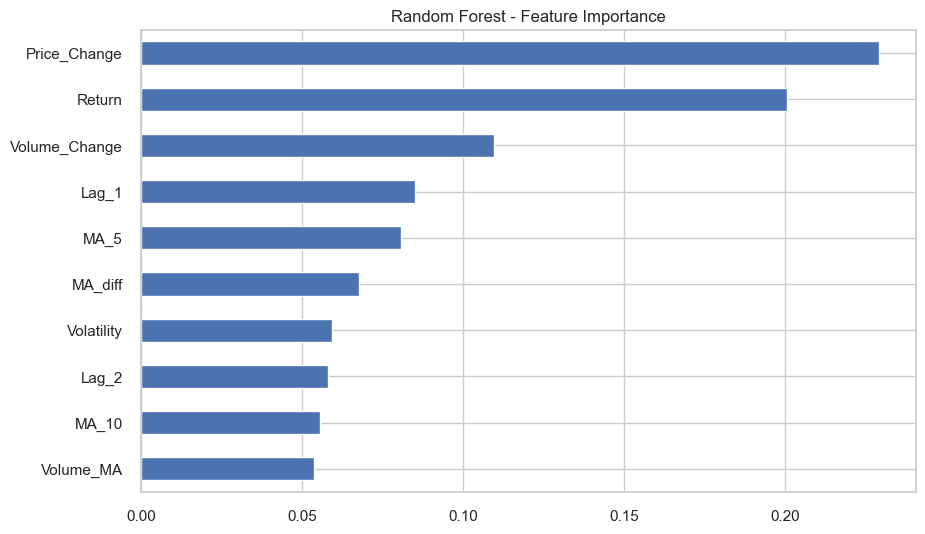

In [8]:
X = df[features]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
print(f"✓ Pipeline trained! Test Accuracy: {pipeline.score(X_test, y_test):.4f}")

# Visualize Feature Importance
importances = pipeline.named_steps['classifier'].feature_importances_
pd.Series(importances, index=features).sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Random Forest - Feature Importance')
plt.show()

### [Cell 9] - Predictions & Results

C:\Users\Nishant\AppData\Local\Temp\ipykernel_5012\3404352122.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Signal', data=results, ax=ax2, palette={'BUY': 'green', 'SELL': 'red', 'HOLD': 'gray'})


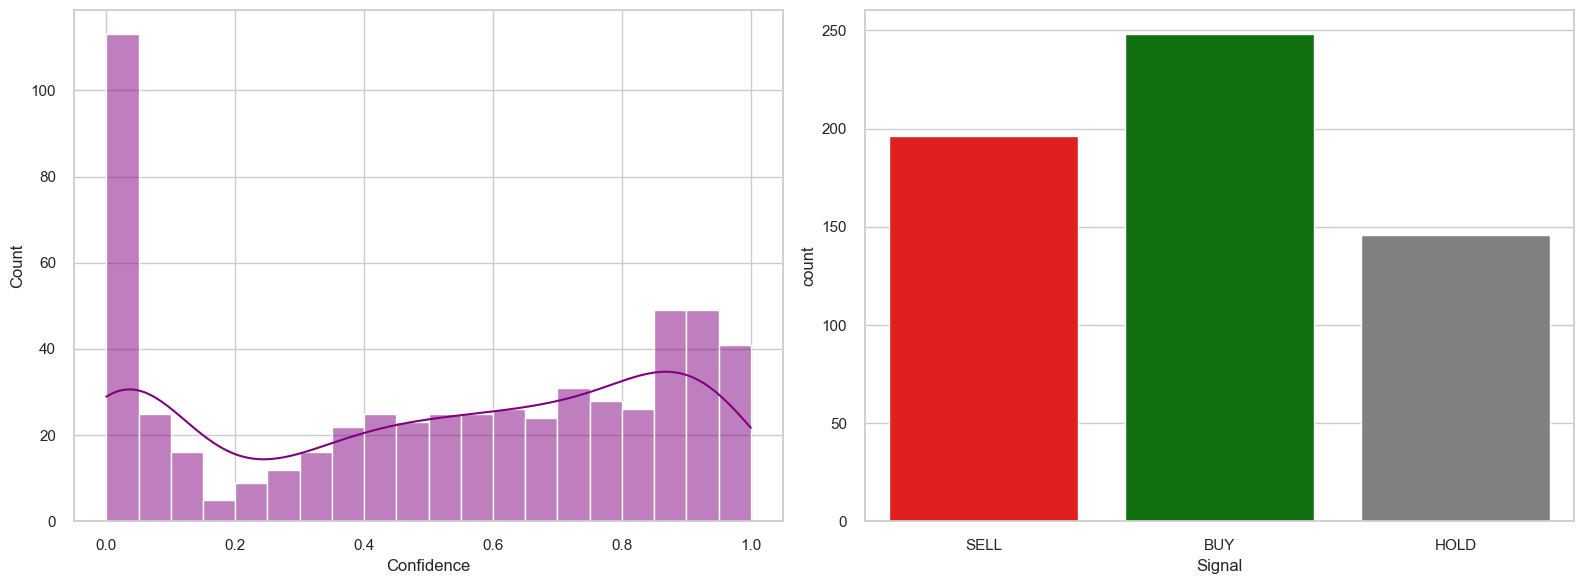

In [9]:
pred = pipeline.predict(X_test)
conf = pipeline.predict_proba(X_test)[:, 1]
results = pd.DataFrame({'Actual': y_test.values, 'Prediction': pred, 'Confidence': conf})
results['Signal'] = results['Confidence'].apply(lambda c: "BUY" if c > 0.65 else ("SELL" if c < 0.35 else "HOLD"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(results['Confidence'], bins=20, kde=True, ax=ax1, color='purple')
sns.countplot(x='Signal', data=results, ax=ax2, palette={'BUY': 'green', 'SELL': 'red', 'HOLD': 'gray'})
plt.tight_layout()
plt.show()

### [Cell 11] - Model Comparison

C:\Users\Nishant\AppData\Local\Temp\ipykernel_5012\676118264.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison, palette='magma')


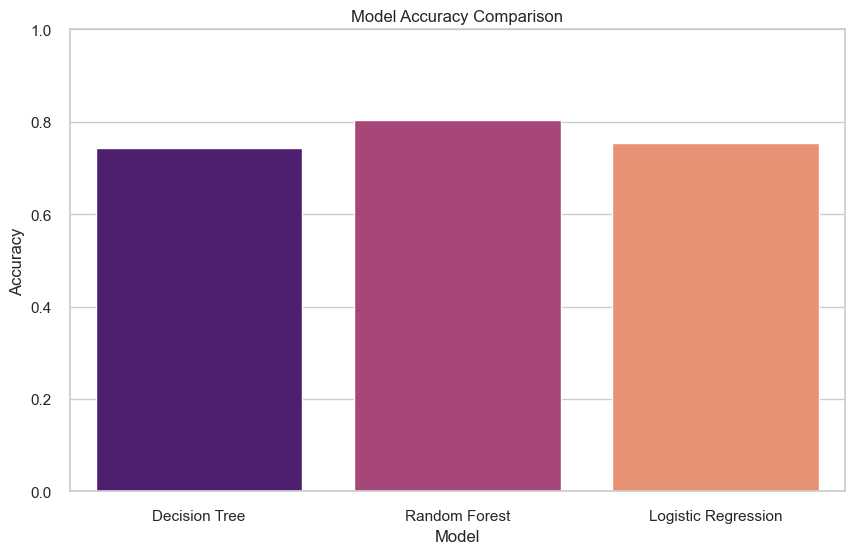

In [10]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500)
}
comparison = pd.DataFrame([
    {'Model': name, 'Accuracy': m.fit(X_train, y_train).score(X_test, y_test)}
    for name, m in models.items()
])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison, palette='magma')
plt.ylim(0, 1.0)
plt.title('Model Accuracy Comparison')
plt.show()